[2026-03-01 15:25:41] === 3銘柄をランダム選択 ===
選ばれた3銘柄:
 - AVAX
 - BTC
 - XRP
[2026-03-01 15:25:41] Fetching AVAX ...
[2026-03-01 15:25:43] Fetching BTC ...
[2026-03-01 15:25:44] Fetching XRP ...


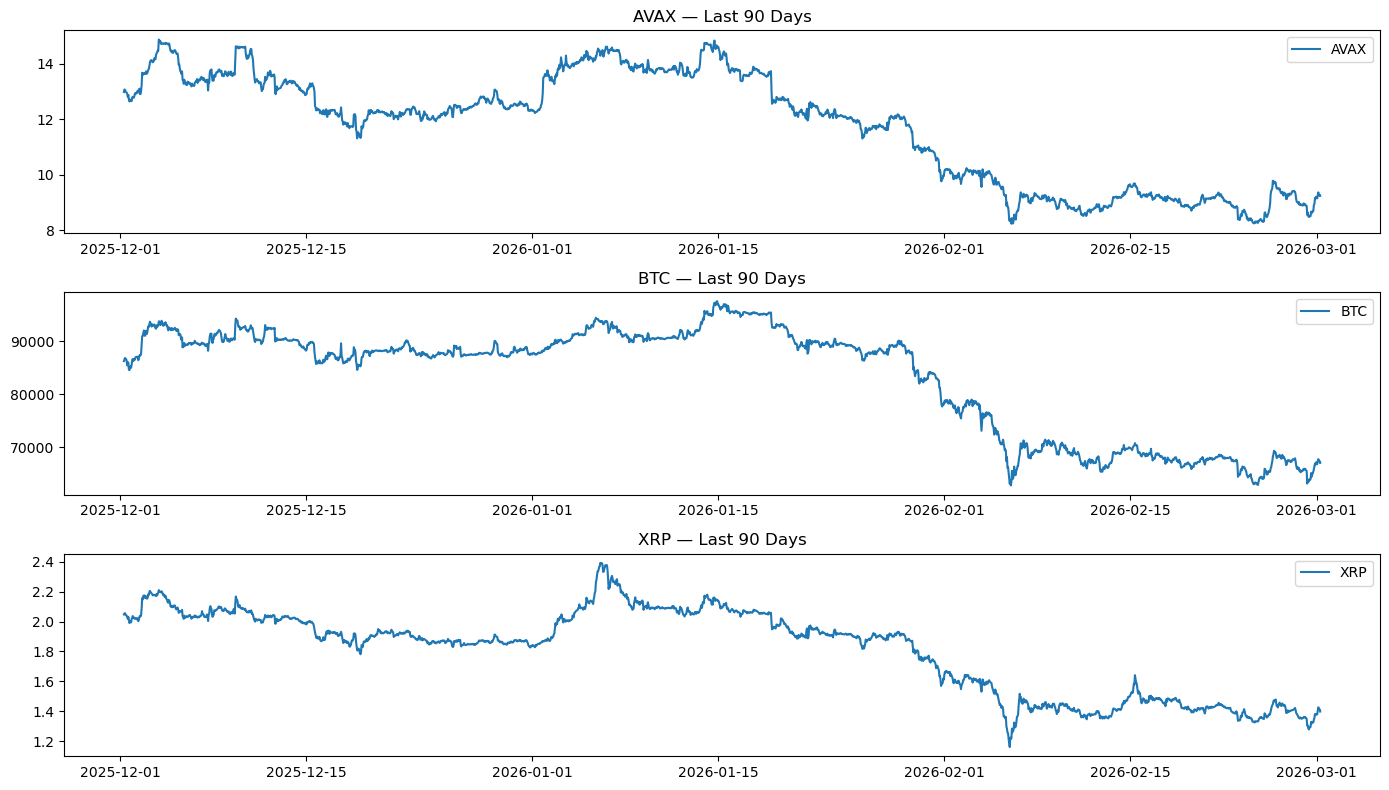

[2026-03-01 15:25:45] === AR を適用 ===
[2026-03-01 15:25:45] Applying AR to AVAX ...
[2026-03-01 15:25:45] [AVAX] AR(5) MSE=5.781287e-05, RMSE=7.603478e-03


c:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


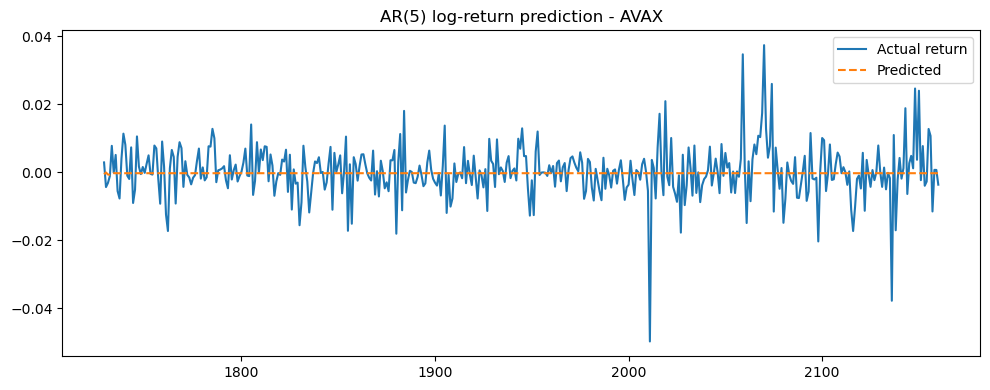

[2026-03-01 15:25:46] Applying AR to BTC ...
[2026-03-01 15:25:46] [BTC] AR(5) MSE=3.189992e-05, RMSE=5.648001e-03


c:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


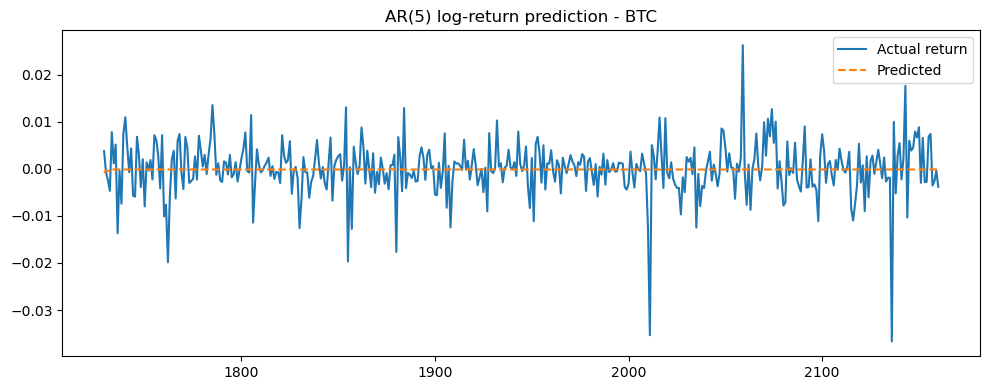

[2026-03-01 15:25:47] Applying AR to XRP ...
[2026-03-01 15:25:47] [XRP] AR(5) MSE=5.825190e-05, RMSE=7.632293e-03


c:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


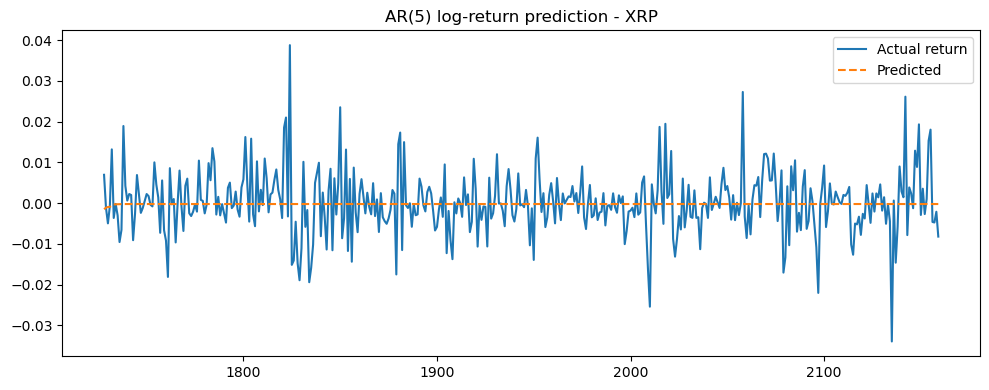

In [1]:
import random
import time
from datetime import datetime

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg


# ------------------------
# 設定
# ------------------------
COINS_POOL = [
    ("bitcoin", "BTC"),
    ("ethereum", "ETH"),
    ("tether", "USDT"),
    ("binancecoin", "BNB"),
    ("solana", "SOL"),
    ("ripple", "XRP"),
    ("usd-coin", "USDC"),
    ("cardano", "ADA"),
    ("dogecoin", "DOGE"),
    ("avalanche-2", "AVAX"),
]

VS = "usd"
DAYS = 90
BASE = "https://api.coingecko.com/api/v3/coins/{id}/market_chart"

session = requests.Session()
session.headers.update({"User-Agent": "Mozilla/5.0"})


def log(msg):
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] {msg}")


# ------------------------
# データ取得
# ------------------------
def fetch_market_chart(coin_id, days=90, vs="usd"):
    url = BASE.format(id=coin_id)
    params = {"vs_currency": vs, "days": days}

    r = session.get(url, params=params, timeout=30)
    r.raise_for_status()

    data = r.json()
    df = pd.DataFrame(data["prices"], columns=["timestamp", "price"])
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
    df = df.sort_values("timestamp")
    return df


# ------------------------
# AR を適用
# ------------------------
def apply_ar(df, symbol, lags=5):
    df = df.copy()
    df["log_price"] = np.log(df["price"])
    df["ret"] = df["log_price"].diff()
    series = df["ret"].dropna()

    train_size = int(len(series) * 0.8)
    train = series.iloc[:train_size]
    test = series.iloc[train_size:]

    model = AutoReg(train, lags=lags, old_names=False)
    res = model.fit()

    pred = res.predict(start=train_size, end=train_size + len(test) - 1)

    mse = ((test.values - pred.values)**2).mean()
    rmse = np.sqrt(mse)

    log(f"[{symbol}] AR({lags}) MSE={mse:.6e}, RMSE={rmse:.6e}")

    # プロット
    plt.figure(figsize=(10,4))
    plt.plot(test.index, test.values, label="Actual return")
    plt.plot(test.index, pred.values, "--", label="Predicted")
    plt.title(f"AR({lags}) log-return prediction - {symbol}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return mse, rmse


# ------------------------
# メイン処理：3選択 → プロット → AR
# ------------------------
def main():
    log("=== 3銘柄をランダム選択 ===")

    selected = random.sample(COINS_POOL, 3)
    print("選ばれた3銘柄:")
    for _, sym in selected:
        print(" -", sym)

    # ---------- 価格プロット ----------
    plt.figure(figsize=(14, 8))

    dfs = {}  # 後で AR に使うため保存

    for idx, (coin_id, symbol) in enumerate(selected, start=1):
        log(f"Fetching {symbol} ...")
        df = fetch_market_chart(coin_id, DAYS, VS)
        dfs[symbol] = df  # 保存しておく

        plt.subplot(3, 1, idx)
        plt.plot(df["timestamp"], df["price"], label=symbol)
        plt.title(f"{symbol} — Last {DAYS} Days")
        plt.legend()
        plt.tight_layout()

        time.sleep(0.5)

    plt.show()

    # ---------- AR 適用 ----------
    log("=== AR を適用 ===")

    for symbol in dfs.keys():
        log(f"Applying AR to {symbol} ...")
        apply_ar(dfs[symbol], symbol)
        time.sleep(0.5)


if __name__ == "__main__":
    main()